In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random
import os
import gc
import time
import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler, EarlyStopping
from tensorflow.keras import regularizers
#from keras.models import load_model
import csv
from itertools import chain

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


In [3]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
cpus = tf.config.experimental.list_physical_devices(device_type='CPU')
print(gpus, cpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
print(tf.__version__)

1.14.0


In [5]:
def reset_seed(seed=42):
    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.set_random_seed(seed)

### 载入数据

In [6]:
data_train=pd.read_csv('F:/TensorFlow/xinjiang/traindata20250619.csv',header=0,encoding='utf_8')
data_train.info()
data_train.className.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Columns: 319 entries, className to Y
dtypes: float64(17), int64(301), object(1)
memory usage: 3.1+ MB


array(['芦苇草甸', '芦苇盐生草甸', '猪毛菜属荒漠', '新疆银穗草草原', '戈壁藜荒漠', '麻黄荒漠', '合头草荒漠',
       '短叶假木贼荒漠', '枇杷柴荒漠', '霸王荒漠', '膜果麻黄荒漠', '疏叶骆驼刺盐生草甸', '柽柳属灌丛',
       '柽柳属荒漠', '花花柴盐生草甸', '裸地', '驼绒藜荒漠', '冷蒿荒漠草原', '芨芨草草原', '旱蒿荒漠',
       '其他针茅草原', '镰芒针茅荒漠草原', '梭梭荒漠', '沙拐枣属荒漠', '紫花针茅草原',
       '新疆银穗草、穗状寒生羊茅荒漠草原', '小针茅荒漠草原', '盐生假木贼荒漠', '线叶嵩草草甸', '绢蒿属荒漠',
       '沙生针茅荒漠草原', '羊茅草原', '早熟禾草甸', '其它薹草草甸', '其它嵩草草甸', '草原苔草、杂类草草甸草原',
       '鸭茅草甸', '小蓬荒漠', '新疆薹草草原', '锦鸡儿属荒漠', '红砂荒漠', '胡杨荒漠', '芦苇荒漠',
       '骆驼刺荒漠'], dtype=object)

In [7]:
pd.set_option('display.max_rows', None)
print(data_train['className'].value_counts())

芦苇草甸                106
裸地                  100
芦苇盐生草甸               79
其他针茅草原               75
柽柳属荒漠                68
梭梭荒漠                 61
紫花针茅草原               51
绢蒿属荒漠                47
驼绒藜荒漠                41
猪毛菜属荒漠               36
疏叶骆驼刺盐生草甸            33
枇杷柴荒漠                29
其它薹草草甸               29
其它嵩草草甸               28
锦鸡儿属荒漠               27
盐生假木贼荒漠              26
旱蒿荒漠                 26
芨芨草草原                24
线叶嵩草草甸               22
花花柴盐生草甸              21
芦苇荒漠                 21
早熟禾草甸                20
麻黄荒漠                 20
羊茅草原                 19
镰芒针茅荒漠草原             19
膜果麻黄荒漠               19
戈壁藜荒漠                18
红砂荒漠                 17
冷蒿荒漠草原               17
胡杨荒漠                 17
沙拐枣属荒漠               16
合头草荒漠                16
短叶假木贼荒漠              14
小蓬荒漠                 14
草原苔草、杂类草草甸草原         13
骆驼刺荒漠                12
霸王荒漠                 12
小针茅荒漠草原              11
新疆银穗草草原              11
柽柳属灌丛                11
鸭茅草甸                 10
沙生针茅荒漠草原        

In [8]:
data_train.head()

,className,num,AET2020,AET2021,AET2101,AET2102,AET2103,AET2104,AET2105,AET2106,...,SR230821b07,SR230829b01,SR230829b02,SR230829b03,SR230829b04,SR230829b05,SR230829b06,SR230829b07,X,Y
0,芦苇草甸,0,39.333333,47.000000,0,32,71,50,66,58,...,1560,1576,2476,921,1406,2463,2369,1910,86.766240,42.038998
1,芦苇盐生草甸,1,47.083333,36.333333,0,9,15,18,82,114,...,3035,2671,3348,1485,2305,3488,3677,3190,84.183913,41.281745
2,芦苇草甸,0,46.500000,42.000000,0,30,36,22,98,127,...,2714,2272,2848,1371,1929,2958,3098,2817,84.276200,41.521080
3,芦苇草甸,0,18.166667,21.750000,0,1,79,8,48,30,...,2167,2044,2916,1104,1752,2971,2739,2031,86.637723,41.022153
4,芦苇盐生草甸,1,9.250000,15.166667,0,0,72,8,42,12,...,2333,1626,2597,836,1359,2653,2585,1955,87.885933,40.463570


In [9]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 类别数量

In [10]:
num_classes = data_train['num'].nunique()
print(num_classes)

44


### 切分数据集（已经提前切分的话不用此部分）

In [11]:
split_index = int(len(data_all)*0.8)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 258 entries, 1272 to 965
Columns: 319 entries, className to Y
dtypes: float64(17), int64(301), object(1)
memory usage: 645.0+ KB


In [12]:
#train_x = data_train.iloc[:,data_train.columns.str.contains("SR")]
#train_x = data_train.iloc[:,~ data_train.columns.str.contains('ClassName|num|SR')]
train_x = data_train.iloc[:,2:]
train_y = data_train.loc[:, ['num']] 

#test_x = data_test.iloc[:,data_train.columns.str.contains("SR")]
#test_x = data_test.iloc[:,~ data_test.columns.str.contains('ClassName|num|SR')]
test_x = data_test.iloc[:,2:]
test_y = data_test.loc[:, ['num']] 
train_x.head(), train_y.head()

(         AET2020     AET2021  AET2101  AET2102  AET2103  AET2104  AET2105  \
 1204    8.916667   15.500000        0       64        4        6       99   
 1230  225.416667  191.083333        0        0        0      401      356   
 165    10.000000   11.583333        0       39        0       32       17   
 368    16.000000   17.083333        0        0        0       12       53   
 332    17.666667   18.000000        0        0        0       11       61   
 
       AET2106  AET2107  AET2108  ...  SR230821b07  SR230829b01  SR230829b02  \
 1204        3        6        2  ...         3710         2661         3014   
 1230      387      476      301  ...         1477         1100         2669   
 165        21       27        2  ...         2684         2110         2792   
 368        64       36       27  ...         1456          702         2967   
 332        70       45       26  ...         2322         1173         2675   
 
       SR230829b03  SR230829b04  SR230829b05  SR

### 顺序编码转独热编码

In [13]:
train_y = tf.keras.utils.to_categorical(train_y)

In [14]:
pd.set_option('display.max_columns', None)

In [15]:
train_y.shape[1]

44

In [16]:
# ====== [1] 对 train_x 做 PCA 降维 ======
pca = PCA(n_components=100)  # 或 n_components='mle' 自动选择维数
train_x = pca.fit_transform(train_x)

In [17]:
print(train_x.shape)  # 应为 (1000, num_features_after_pca)
print(train_y.shape)  # 应为 (1000, 44)
dim_num = train_x.shape[1]

(1028, 100)
(1028, 44)


In [18]:
# ====== [2] 计算类别权重 ======
y_labels = np.argmax(train_y, axis=1)
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=y_labels)
class_weights = dict(enumerate(class_weights_array))

In [19]:
# ====== [3] 定义改进版 focal loss ======
def multi_category_focal_loss2(gamma=2., alpha=.25, class_weights=None):
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)
    
    if class_weights is not None:
        # 转换 numpy array 或 dict 为 tf.constant
        if isinstance(class_weights, dict):
            weights = np.array([class_weights[i] for i in range(len(class_weights))])
        else:
            weights = np.array(class_weights)
        class_weights_tf = tf.constant(weights, dtype=tf.float32)
    else:
        class_weights_tf = None

    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # alpha 调整
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        y_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        ce = -tf.math.log(y_t)
        weight = tf.pow(1. - y_t, gamma)
        fl = alpha_t * weight * ce

        if class_weights_tf is not None:
            # 按类别权重加权
            fl = fl * class_weights_tf

        return tf.reduce_mean(fl)

    return focal_loss_fixed

### 模型构建

In [20]:
# 学习率衰减函数
def lr_schedule(epoch):
    lr = 1e-3
    if epoch > 100:
        lr *= 0.5
    if epoch > 200:
        lr *= 0.5
    return lr
reduce_lr = LearningRateScheduler(lr_schedule)

reset_seed()
# ====== [4] 模型结构简化 ======
def build_model(input_dim, num_classes):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(512, input_dim=input_dim, activation='relu', 
                                    kernel_regularizer=regularizers.l2(0.001)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(0.4))
    model.add(tf.keras.layers.Dense(256, activation='relu', 
                                    kernel_regularizer=regularizers.l2(0.001)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(0.4))
    model.add(tf.keras.layers.Dense(128, activation='relu', 
                                    kernel_regularizer=regularizers.l2(0.001)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(0.4))
    model.add(tf.keras.layers.Dense(64, activation='relu', 
                                    kernel_regularizer=regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
    return model
# ====== [5] 构建模型 ======
model = build_model(input_dim=train_x.shape[1], num_classes=num_classes)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(loss=multi_category_focal_loss2(alpha=0.25, gamma=2),
              optimizer=optimizer,
              metrics=['accuracy'])

model.summary()

# ====== [6] 学习率调度器 ======
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=10, verbose=1)


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               51712     
_________________________________________________________________
batch_normalization (BatchNo (None, 512)               2048      
_________________________________________________________________
dropout (Dropout)            (None, 512)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 256)               131328    
_________________________________________________________________
batch_normalization_1 (Batch (None, 256)               1024      
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
___

### 开始训练

In [21]:
# ====== [7] 开始训练 ======
epochs = 500
batch_size = 64

# 在训练时加入噪声作为一种数据扩充方法
train_x_noisy = train_x + np.random.normal(0, 0.1, train_x.shape)

early_stopping = EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)

start = time.perf_counter()
history = model.fit(train_x_noisy, train_y,
                    epochs=epochs,
                    batch_size=batch_size,
                    verbose=1,
                    callbacks=[reduce_lr, early_stopping])

hours, rem = divmod(time.perf_counter() - start, 3600)
mins, secs = divmod(rem, 60)
print("训练时间：%02d:%02d:%02d" % (hours, mins, secs))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/500
1028/1028 [==============================] - 1s 658us/sample - loss: 0.6607 - acc: 0.0360
Epoch 2/500
1028/1028 [==============================] - 0s 79us/sample - loss: 0.4346 - acc: 0.0759
Epoch 3/500
1028/1028 [==============================] - 0s 72us/sample - loss: 0.2885 - acc: 0.1274
Epoch 4/500
1028/1028 [==============================] - 0s 72us/sample - loss: 0.1953 - acc: 0.1693
Epoch 5/500
1028/1028 [==============================] - 0s 68us/sample - loss: 0.1358 - acc: 0.2014
Epoch 6/500
1028/1028 [==============================] - 0s 73us/sample - loss: 0.0981 - acc: 0.2053
Epoch 7/500
1028/1028 [==============================] - 0s 78us/sample - loss: 0.0732 - acc: 0.2082
Epoch 8/500
1028/1028 [==============================] - 0s 74us/sample - loss: 0.0568 - acc: 0.2286
Epoch 9/500
1028/1028 [==============================] - 0s 79us/sample - loss: 0.0458 - acc: 0.2

1028/1028 [==============================] - 0s 100us/sample - loss: 0.0135 - acc: 0.4125
Epoch 75/500
1028/1028 [==============================] - 0s 86us/sample - loss: 0.0136 - acc: 0.4125
Epoch 76/500
1028/1028 [==============================] - 0s 73us/sample - loss: 0.0135 - acc: 0.4241
Epoch 77/500
1028/1028 [==============================] - 0s 71us/sample - loss: 0.0137 - acc: 0.4066
Epoch 78/500
1028/1028 [==============================] - 0s 68us/sample - loss: 0.0138 - acc: 0.4018
Epoch 79/500
1028/1028 [==============================] - 0s 79us/sample - loss: 0.0134 - acc: 0.4212
Epoch 80/500
1028/1028 [==============================] - 0s 71us/sample - loss: 0.0135 - acc: 0.4173
Epoch 81/500
1028/1028 [==============================] - 0s 72us/sample - loss: 0.0136 - acc: 0.4047
Epoch 82/500
1028/1028 [==============================] - 0s 68us/sample - loss: 0.0140 - acc: 0.3969
Epoch 83/500
1028/1028 [==============================] - 0s 71us/sample - loss: 0.0140 - acc:

1028/1028 [==============================] - 0s 71us/sample - loss: 0.0099 - acc: 0.5973
Epoch 153/500
1028/1028 [==============================] - 0s 77us/sample - loss: 0.0103 - acc: 0.5516
Epoch 154/500
1028/1028 [==============================] - 0s 76us/sample - loss: 0.0101 - acc: 0.5875
Epoch 155/500
1028/1028 [==============================] - 0s 75us/sample - loss: 0.0099 - acc: 0.6070
Epoch 156/500
1028/1028 [==============================] - 0s 73us/sample - loss: 0.0101 - acc: 0.5905
Epoch 157/500
1028/1028 [==============================] - 0s 77us/sample - loss: 0.0101 - acc: 0.5856
Epoch 158/500
1028/1028 [==============================] - 0s 74us/sample - loss: 0.0098 - acc: 0.6080
Epoch 159/500
1028/1028 [==============================] - 0s 90us/sample - loss: 0.0100 - acc: 0.5895
Epoch 160/500
1028/1028 [==============================] - 0s 94us/sample - loss: 0.0100 - acc: 0.6041
Epoch 161/500
 704/1028 [===================>..........] - ETA: 0s - loss: 0.0099 - acc

 832/1028 [=======================>......] - ETA: 0s - loss: 0.0077 - acc: 0.7224
Epoch 00230: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
1028/1028 [==============================] - 0s 75us/sample - loss: 0.0077 - acc: 0.7305
Epoch 231/500
1028/1028 [==============================] - 0s 82us/sample - loss: 0.0076 - acc: 0.7296
Epoch 232/500
1028/1028 [==============================] - 0s 83us/sample - loss: 0.0075 - acc: 0.7451
Epoch 233/500
1028/1028 [==============================] - 0s 74us/sample - loss: 0.0075 - acc: 0.7364
Epoch 234/500
1028/1028 [==============================] - 0s 78us/sample - loss: 0.0075 - acc: 0.7422
Epoch 235/500
1028/1028 [==============================] - 0s 82us/sample - loss: 0.0074 - acc: 0.7617
Epoch 236/500
1028/1028 [==============================] - 0s 81us/sample - loss: 0.0075 - acc: 0.7305
Epoch 237/500
1028/1028 [==============================] - 0s 79us/sample - loss: 0.0075 - acc: 0.7500
Epoch 238/500
1028/1028 [===

1028/1028 [==============================] - 0s 74us/sample - loss: 0.0066 - acc: 0.8074
Epoch 302/500
1028/1028 [==============================] - 0s 84us/sample - loss: 0.0065 - acc: 0.8006
Epoch 303/500
1028/1028 [==============================] - 0s 84us/sample - loss: 0.0066 - acc: 0.7967
Epoch 304/500
1028/1028 [==============================] - 0s 71us/sample - loss: 0.0066 - acc: 0.8045
Epoch 305/500
1028/1028 [==============================] - 0s 69us/sample - loss: 0.0066 - acc: 0.7996
Epoch 306/500
1028/1028 [==============================] - 0s 83us/sample - loss: 0.0064 - acc: 0.8268
Epoch 307/500
1028/1028 [==============================] - 0s 79us/sample - loss: 0.0067 - acc: 0.7938
Epoch 308/500
1028/1028 [==============================] - 0s 88us/sample - loss: 0.0065 - acc: 0.8025
Epoch 309/500
1028/1028 [==============================] - 0s 74us/sample - loss: 0.0065 - acc: 0.8171
Epoch 310/500
1028/1028 [==============================] - 0s 70us/sample - loss: 0.006

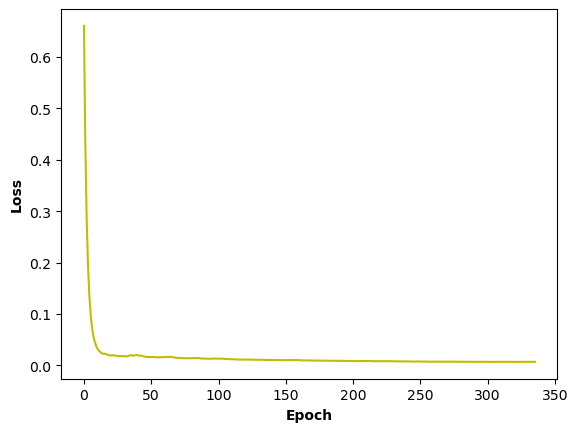

In [29]:
# 自动获取实际训练轮数
actual_epochs = len(history.history['loss'])
# 设置字体
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.plot(range(actual_epochs),history.history.get('loss'),color =  'y')
plt.savefig('XJloss20250620.png', bbox_inches='tight', pad_inches=0.0, dpi = 600)

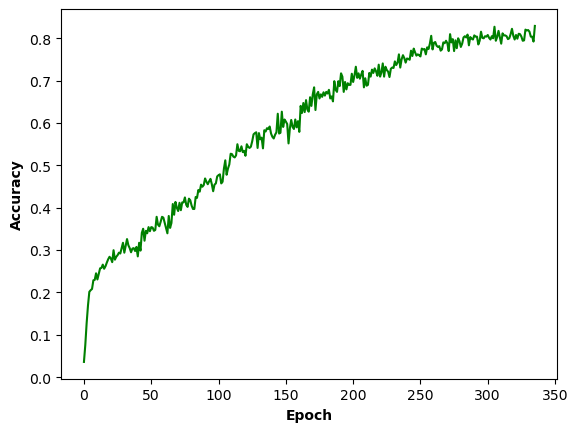

In [30]:
# 设置字体
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.plot(range(actual_epochs),history.history.get('acc'),color =  'g')
plt.savefig('XJacc20250620.png', bbox_inches='tight', pad_inches=0.0, dpi = 600)

### 计算准确率

In [24]:
test_x = pca.transform(test_x)
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
# Accuracy
acc = accuracy_score(test_y, test_r)

# Precision, Recall, F1 (macro平均适用于多分类)
precision = precision_score(test_y, test_r, average='macro')
recall = recall_score(test_y, test_r, average='macro')
f1 = f1_score(test_y, test_r, average='macro')

# Confusion Matrix
cm = confusion_matrix(test_y, test_r)

print("Accuracy:", acc)
print("Precision (macro):", precision)
print("Recall (macro):", recall)
print("F1 Score (macro):", f1)
print("Confusion Matrix:\n", cm)

258/258 [==============================] - 0s 260us/sample
Accuracy: 0.4069767441860465
Precision (macro): 0.292052376506158
Recall (macro): 0.2614783243072717
F1 Score (macro): 0.2510206262989384
Confusion Matrix:
 [[12  6  0 ...  0  1  0]
 [ 2 11  0 ...  0  0  0]
 [ 0  0  2 ...  0  0  0]
 ...
 [ 0  0  0 ...  1  0  0]
 [ 1  0  0 ...  1  2  0]
 [ 0  0  0 ...  0  0  0]]


D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### 各类别准确率

In [25]:
# 创建 num 到 className 的映射（取 data_train 中唯一的映射关系）
num_to_name = data_train.drop_duplicates(subset='num').set_index('num')['className'].to_dict()

# 每类准确率 = 对角线元素 / 该类总数（行和）
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# 每类样本数量（即该类在混淆矩阵中的行和）
per_class_count = cm.sum(axis=1)

num_classes_cm = cm.shape[0]  # 43
for i in range(num_classes_cm):
    name = num_to_name.get(i, f"类{i}")
    acc = per_class_accuracy[i]
    count = per_class_count[i]
    print(f"{name}: acc: {acc:.2%}，count: {count}")

芦苇草甸: acc: 60.00%，count: 20
芦苇盐生草甸: acc: 68.75%，count: 16
猪毛菜属荒漠: acc: 33.33%，count: 6
新疆银穗草草原: acc: 25.00%，count: 4
戈壁藜荒漠: acc: 66.67%，count: 3
麻黄荒漠: acc: 50.00%，count: 6
合头草荒漠: acc: 0.00%，count: 3
短叶假木贼荒漠: acc: 25.00%，count: 4
枇杷柴荒漠: acc: 0.00%，count: 3
霸王荒漠: acc: 0.00%，count: 1
膜果麻黄荒漠: acc: 50.00%，count: 4
疏叶骆驼刺盐生草甸: acc: 50.00%，count: 4
柽柳属灌丛: acc: 0.00%，count: 3
柽柳属荒漠: acc: 21.43%，count: 14
花花柴盐生草甸: acc: 0.00%，count: 2
裸地: acc: 76.92%，count: 26
驼绒藜荒漠: acc: 83.33%，count: 6
冷蒿荒漠草原: acc: 16.67%，count: 6
芨芨草草原: acc: 16.67%，count: 6
旱蒿荒漠: acc: 60.00%，count: 5
其他针茅草原: acc: 42.11%，count: 19
镰芒针茅荒漠草原: acc: 0.00%，count: 2
梭梭荒漠: acc: 63.16%，count: 19
沙拐枣属荒漠: acc: 0.00%，count: 2
紫花针茅草原: acc: 27.27%，count: 11
新疆银穗草、穗状寒生羊茅荒漠草原: acc: 0.00%，count: 1
小针茅荒漠草原: acc: 28.57%，count: 7
盐生假木贼荒漠: acc: 0.00%，count: 5
线叶嵩草草甸: acc: 40.00%，count: 10
绢蒿属荒漠: acc: nan%，count: 0
沙生针茅荒漠草原: acc: 0.00%，count: 3
羊茅草原: acc: 0.00%，count: 4
早熟禾草甸: acc: 33.33%，count: 3
其它薹草草甸: acc: 0.00%，count: 4
其它嵩草草甸: acc: 0.00%，coun

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in true_divide
  """


In [26]:
# 转成 DataFrame，方便处理
df_test = pd.DataFrame({
    'num': test_y.iloc[:, 0].values,    # 从 DataFrame 中取出标签列
    'pred': test_r.flatten()            # 如果 test_r 是 numpy array
})

# 读入 num 到 植被型 的映射表
map_df = pd.read_csv('F:/TensorFlow/xinjiang/新疆20240718所有类别.csv', header=0, encoding='utf_8')  # 包含列：num，植被型

# 添加真实大类列
df_test = df_test.merge(map_df[['num', '植被型']], on='num', how='left')
df_test = df_test.rename(columns={'植被型': '真实植被型'})

# 添加预测大类列（通过预测的 pred 映射）
df_test = df_test.merge(map_df[['num', '植被型']], left_on='pred', right_on='num', how='left')
df_test = df_test.rename(columns={'植被型': '预测植被型'})
df_test = df_test.drop(columns=['num_y'])  # 删除多余列
df_test = df_test.rename(columns={'num_x': 'num'})  # 恢复 num

# 🧼【修正部分】：去掉包含 NaN 的行并转换为字符串
df_eval = df_test.dropna(subset=['真实植被型', '预测植被型']).copy()
y_true_big = df_eval['真实植被型'].astype(str)
y_pred_big = df_eval['预测植被型'].astype(str)

# ✅ 计算评估指标
acc = accuracy_score(y_true_big, y_pred_big)
precision = precision_score(y_true_big, y_pred_big, average='macro')
recall = recall_score(y_true_big, y_pred_big, average='macro')
f1 = f1_score(y_true_big, y_pred_big, average='macro')

# ✅ 混淆矩阵（确保标签一致顺序）
labels = sorted(y_true_big.unique())
conf_mat = confusion_matrix(y_true_big, y_pred_big, labels=labels)

# ✅ 输出
print(f"【大类层级总体指标】")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

【大类层级总体指标】
Accuracy : 0.5116
Precision: 0.4472
Recall   : 0.3916
F1 Score : 0.3858


In [27]:
print(f"\n被排除的样本数（含NaN大类）: {len(df_test) - len(df_eval)}")


被排除的样本数（含NaN大类）: 0


In [28]:
# 统计每个植被型的测试数量和准确数
summary = (
    df_test
    .groupby('真实植被型')
    .agg(
        测试数量=('真实植被型', 'count'),
        正确数量=('预测植被型', lambda x: (x == df_test.loc[x.index, '真实植被型']).sum())
    )
    .assign(准确率=lambda df: df['正确数量'] / df['测试数量'])
    .sort_values('测试数量', ascending=False)
)

# 输出
print(summary.reset_index().to_string(index=False))

   真实植被型  测试数量  正确数量      准确率
半灌木与草本荒漠    85    58 0.682353
   半灌木草甸    31    23 0.741935
  丛生草类草原    26     3 0.115385
  根茎草类草甸    26    15 0.576923
   半灌木草原    21     7 0.333333
   杂类草草甸    19     8 0.421053
      裸地    19    12 0.631579
半乔木与灌木荒漠    12     2 0.166667
  丛生草类草甸     9     2 0.222222
  落叶阔叶灌丛     6     1 0.166667
   杂类草草原     4     1 0.250000


In [31]:
model.save(r'F:/TensorFlow/model_data/model_XJ_20250620.h5')